# Install Packages

In [1]:
!pip install shap imbalanced-learn adversarial-robustness-toolbox -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.2 MB/s eta 0:00:00 0:00:01


# Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
    matthews_corrcoef, accuracy_score, roc_auc_score, roc_curve, auc)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, LSTM, Bidirectional, MultiHeadAttention, LayerNormalization,
    Concatenate, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import BorderlineSMOTE
import warnings; warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv', low_memory=False)

print(f'\nDataset shape: {df.shape}')
print(f'Total samples: {df.shape[0]:,}')
print(f'Total features: {df.shape[1]}')
df.head()

2026-04-28 00:29:59.342740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777336199.567932      54 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777336199.634731      54 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777336200.151965      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777336200.152004      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777336200.152007      54 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: True

Dataset shape: (2219201, 63)
Total samples: 2,219,201
Total features: 63


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


# Class Distribution

Attack type distribution:
Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64

Total classes: 15


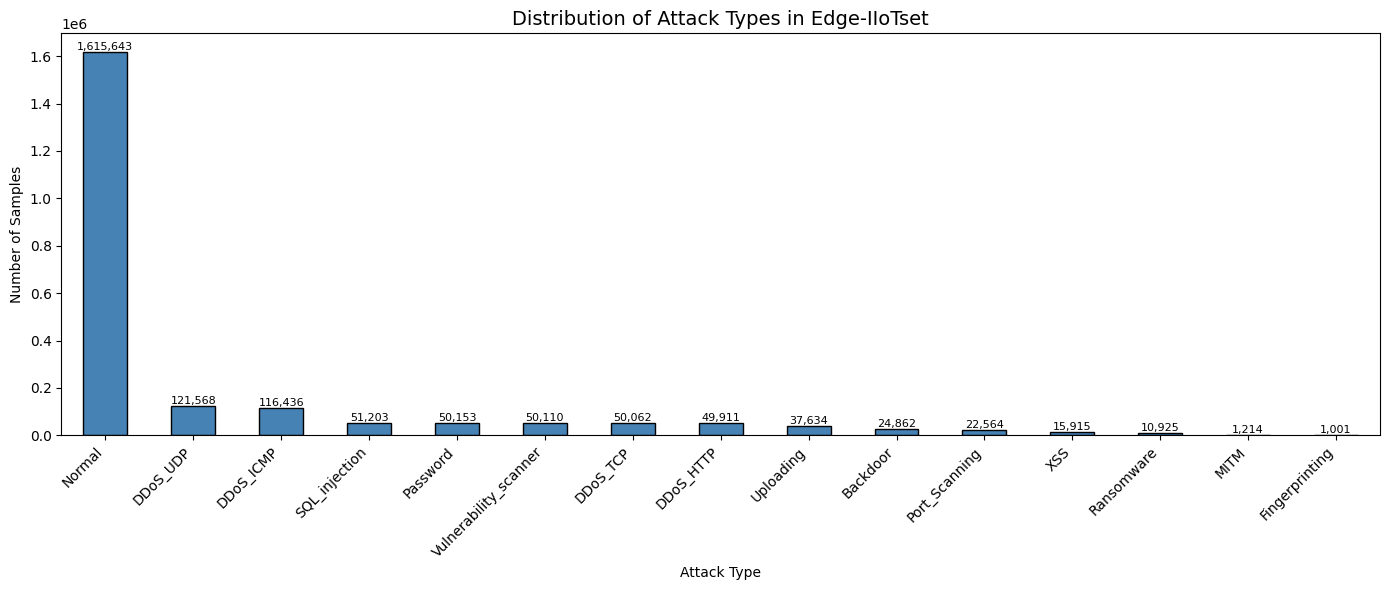

In [3]:
print('Attack type distribution:')
print(df['Attack_type'].value_counts())
print(f'\nTotal classes: {df["Attack_type"].nunique()}')

plt.figure(figsize=(14, 6))
ax = df['Attack_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Attack Types in Edge-IIoTset', fontsize=14)
plt.xlabel('Attack Type'); plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height()):,}', (bar.get_x()+bar.get_width()/2., bar.get_height()),
        ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

# Data Cleaning and Preprocessing

In [4]:
# Drop non-behavioural columns
drop_columns = ['frame.time','ip.src_host','ip.dst_host','arp.src.proto_ipv4',
    'arp.dst.proto_ipv4','http.file_data','http.request.full_uri',
    'icmp.transmit_timestamp','http.request.uri.query','tcp.options',
    'tcp.payload','tcp.srcport','tcp.dstport','udp.port','mqtt.msg']

# Only drop columns that actually exist in the dataframe
existing_drops = [c for c in drop_columns if c in df.columns]
df.drop(existing_drops, axis=1, inplace=True)
print(f'Dropped {len(existing_drops)} non-behavioural columns')
print(f'Remaining columns: {df.shape[1]}')

# Handle missing values
print(f'\nMissing values: {df.isnull().sum().sum()}')
df.dropna(axis=0, how='any', inplace=True)
print(f'After dropping NaN: {df.shape[0]:,}')

# Remove duplicates 
before = df.shape[0]; df.drop_duplicates(keep='first', inplace=True)
print(f'Removed {before-df.shape[0]:,} duplicates')
print(f'Final: {df.shape[0]:,} samples, {df.shape[1]} columns')

# Encode categorical columns 
# Separate features and target
target_col = 'Attack_type'; X = df.drop(target_col, axis=1); y = df[target_col]

# Identify and encode any remaining object/string columns
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder(); X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le; print(f'  Encoded: {col}')
    
# Encode the target variable
target_encoder = LabelEncoder(); y_encoded = target_encoder.fit_transform(y)
class_names = target_encoder.classes_; print(f'\nClasses: {list(class_names)}')

Dropped 15 non-behavioural columns
Remaining columns: 48

Missing values: 0
After dropping NaN: 2,219,201
Removed 309,530 duplicates
Final: 1,909,671 samples, 48 columns
  Encoded: http.request.method
  Encoded: http.referer
  Encoded: http.request.version
  Encoded: dns.qry.name.len
  Encoded: mqtt.conack.flags
  Encoded: mqtt.protoname
  Encoded: mqtt.topic

Classes: ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner', 'XSS']


# Strategic Subsampling

In [5]:
# This is done because 2.2 million samples is computationally prohibitive for 
# Transformer training on CPU.Hence, Subsampling is standard practice
# (Ferrag et al., 2022 did this for their ML experiments).
# Stratified sampling is used to preserve class proportions.
SAMPLE_FRACTION = 0.15

X_sampled, _, y_sampled, _ = train_test_split(X, y_encoded, train_size=SAMPLE_FRACTION,
    stratify=y_encoded, random_state=42)

print(f'Sampled dataset: {X_sampled.shape[0]:,} samples')
print(f'\nClass distribution:')
unique, counts = np.unique(y_sampled, return_counts=True)
for idx, cnt in zip(unique, counts): print(f'  {class_names[idx]}: {cnt:,}')

Sampled dataset: 286,450 samples

Class distribution:
  Backdoor: 3,604
  DDoS_HTTP: 7,282
  DDoS_ICMP: 10,191
  DDoS_TCP: 7,509
  DDoS_UDP: 18,235
  Fingerprinting: 128
  MITM: 54
  Normal: 204,599
  Password: 7,490
  Port_Scanning: 2,996
  Ransomware: 1,453
  SQL_injection: 7,624
  Uploading: 5,521
  Vulnerability_scanner: 7,504
  XSS: 2,260


# Train/Test Split + Feature Scaling

In [6]:
# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sampled, y_sampled, test_size=0.20, stratify=y_sampled, random_state=42)

# Second split: from the 80%, take 20% as validation (= 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=42)

print(f'Training set:   {X_train.shape[0]:,} samples (64% of total)')
print(f'Validation set: {X_val.shape[0]:,} samples (16% of total)')
print(f'Test set:       {X_test.shape[0]:,} samples (20% of total)')

# Feature scaling - fit ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)  
X_test_scaled = scaler.transform(X_test)  # Use train statistics!

num_features = X_train_scaled.shape[1]; num_classes = len(class_names)
print(f'\nFeatures: {num_features} | Classes: {num_classes}')

Training set:   183,328 samples (64% of total)
Validation set: 45,832 samples (16% of total)
Test set:       57,290 samples (20% of total)

Features: 47 | Classes: 15


# Borderline-SMOTE

In [7]:
# SMOTE is applied to TRAINING data ONLY. Applying it to
# test data would artificially inflate performance metrics, making
# the model appear better than it actually is on real-world dat
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')

try:
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
    print(f'Before SMOTE: {X_train_scaled.shape[0]:,}')
    print(f'After SMOTE:  {X_train_res.shape[0]:,}')
    print(f'\nResampled distribution:')
    u, cnt = np.unique(y_train_res, return_counts=True)
    for i, n in zip(u, cnt): print(f'  {class_names[i]}: {n:,}')
except:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
    print('Used regular SMOTE (Borderline failed)')

Before SMOTE: 183,328
After SMOTE:  1,964,145

Resampled distribution:
  Backdoor: 130,943
  DDoS_HTTP: 130,943
  DDoS_ICMP: 130,943
  DDoS_TCP: 130,943
  DDoS_UDP: 130,943
  Fingerprinting: 130,943
  MITM: 130,943
  Normal: 130,943
  Password: 130,943
  Port_Scanning: 130,943
  Ransomware: 130,943
  SQL_injection: 130,943
  Uploading: 130,943
  Vulnerability_scanner: 130,943
  XSS: 130,943


# Prepare Data for Neural Networks

In [8]:
# Reshape for Conv1D: (samples, features, 1)
X_train_nn = X_train_res.reshape(-1, num_features, 1)
X_val_nn = X_val_scaled.reshape(-1, num_features, 1)
X_test_nn = X_test_scaled.reshape(-1, num_features, 1)

# One-hot encode targets
y_train_oh = to_categorical(y_train_res, num_classes)
y_val_oh = to_categorical(y_val, num_classes)
y_test_oh = to_categorical(y_test, num_classes)

print(f'Train shape: {X_train_nn.shape}')
print(f'Val shape:   {X_val_nn.shape}')
print(f'Test shape:  {X_test_nn.shape}')

Train shape: (1964145, 47, 1)
Val shape:   (45832, 47, 1)
Test shape:  (57290, 47, 1)


# Baseline Model — Random Forest

Training Random Forest...

=== Random Forest Results ===
Accuracy: 0.9778 | F1 macro: 0.8976 | MCC: 0.9540

                       precision    recall  f1-score   support

             Backdoor       0.98      0.97      0.97       721
            DDoS_HTTP       0.93      0.75      0.83      1456
            DDoS_ICMP       1.00      0.99      1.00      2038
             DDoS_TCP       1.00      1.00      1.00      1502
             DDoS_UDP       1.00      1.00      1.00      3647
       Fingerprinting       0.58      0.69      0.63        26
                 MITM       1.00      1.00      1.00        11
               Normal       1.00      1.00      1.00     40920
             Password       0.82      0.85      0.83      1498
        Port_Scanning       0.97      0.99      0.98       599
           Ransomware       0.94      0.92      0.93       290
        SQL_injection       0.90      0.78      0.84      1525
            Uploading       0.77      0.87      0.82      1104
Vulnerabi

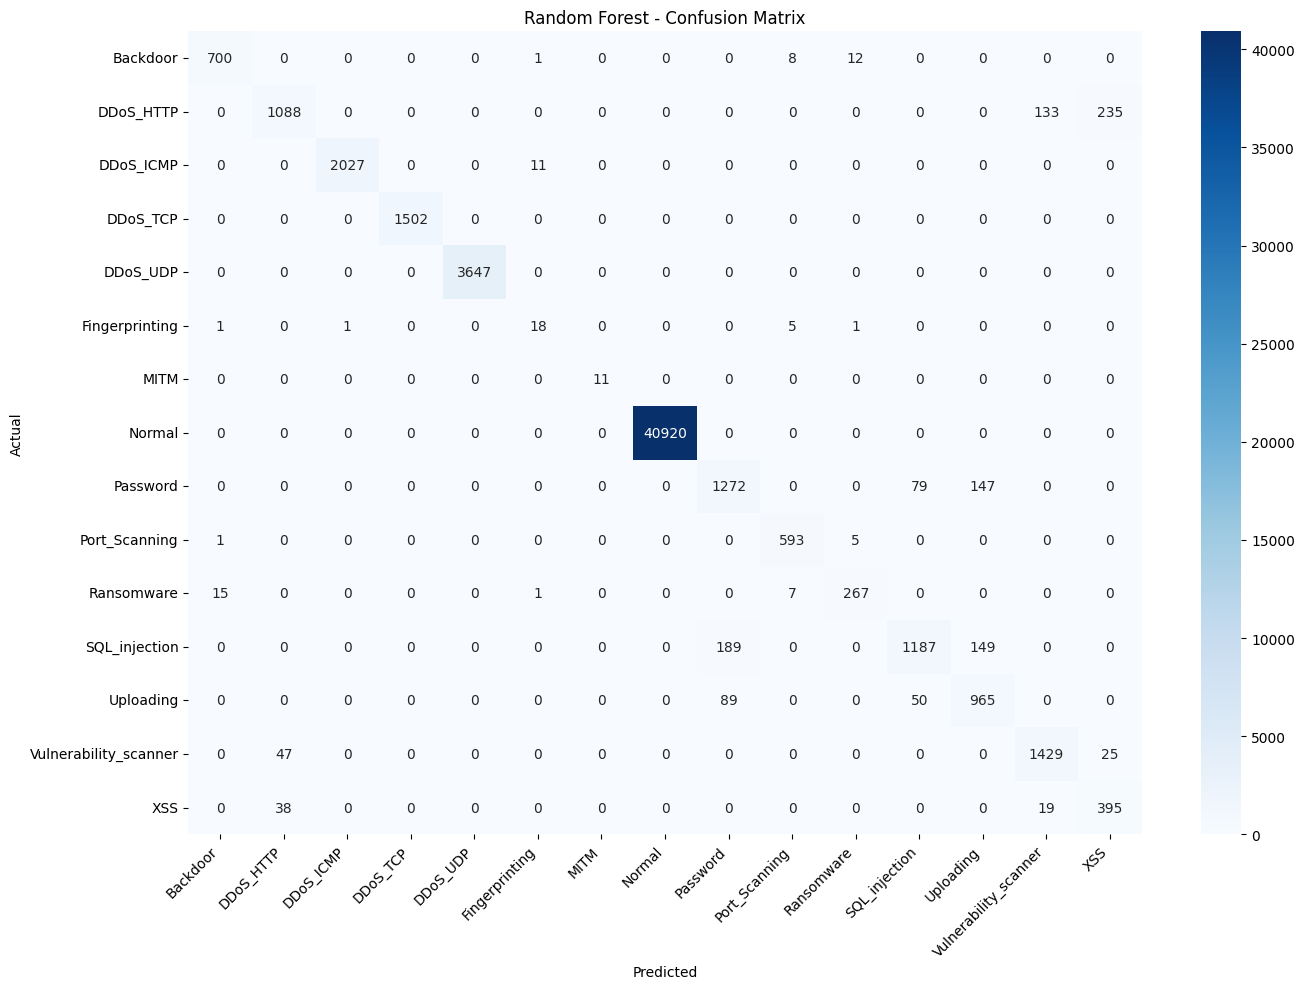

In [9]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)

print('Training Random Forest...')
rf.fit(X_train_res, y_train_res)

# Evaluate
y_pred_rf = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_mcc = matthews_corrcoef(y_test, y_pred_rf)

print(f'\n=== Random Forest Results ===')
print(f'Accuracy: {rf_acc:.4f} | F1 macro: {rf_f1:.4f} | MCC: {rf_mcc:.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=class_names)}')

# Save confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(14,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('rf_cm.png', dpi=150, bbox_inches='tight'); plt.show()

# Standalone CNN

In [10]:
# CNNs excel at identifying local patterns in feature
# vectors but cannot capture temporal dependencies or long-range
# feature interactions.

# Build standalone CNN
def build_cnn(inp_shape, n_cls):
    inp = Input(shape=inp_shape)
    x = Conv1D(64, 3, padding='same')(inp); x = BatchNormalization()(x); x = ReLU()(x)
    x = Conv1D(128, 3, padding='same')(x); x = BatchNormalization()(x); x = ReLU()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(256, 3, padding='same')(x); x = BatchNormalization()(x); x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x); x = Dropout(0.3)(x)
    out = Dense(n_cls, activation='softmax')(x)
    return Model(inp, out, name='CNN')

cnn = build_cnn((num_features,1), num_classes)
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

h_cnn = cnn.fit(X_train_nn, y_train_oh, epochs=30, batch_size=256,
    validation_data=(X_val_nn, y_val_oh),  # REAL validation data!
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)], verbose=1)
# Evaluate
y_p_cnn = np.argmax(cnn.predict(X_test_nn), axis=1)
cnn_acc = accuracy_score(y_test, y_p_cnn); cnn_f1 = f1_score(y_test, y_p_cnn, average='macro')
cnn_mcc = matthews_corrcoef(y_test, y_p_cnn)
print(f'\n=== CNN Results ===')
print(f'Accuracy: {cnn_acc:.4f} | F1 macro: {cnn_f1:.4f} | MCC: {cnn_mcc:.4f}')

I0000 00:00:1777336446.561370      54 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777336446.567956      54 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 47, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 23, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 23, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,143 (625.56 KB)

 Trainable params: 159,247 (622.06 KB)

...

Epoch 1/30


I0000 00:00:1777336452.127648     202 service.cc:152] XLA service 0x7967780099f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777336452.127683     202 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777336452.127687     202 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777336452.671391     202 cuda_dnn.cc:529] Loaded cuDNN version 91002


  21/7673 ━━━━━━━━━━━━━━━━━━━━ 1:01 8ms/step - accuracy: 0.2469 - loss: 2.3546

I0000 00:00:1777336456.724958     202 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7673/7673 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - accuracy: 0.6280 - loss: 0.7041 - val_accuracy: 0.8882 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 2/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.6723 - loss: 0.5926 - val_accuracy: 0.9286 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 3/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.6831 - loss: 0.5760 - val_accuracy: 0.9126 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 4/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.6902 - loss: 0.5657 - val_accuracy: 0.8051 - val_loss: 0.5452 - learning_rate: 0.0010
Epoch 5/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.6940 - loss: 0.5599 - val_accuracy: 0.9303 - val_loss: 0.1378 - learning_rate: 0.0010
Epoch 6/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.6994 - loss: 0.5516 - val_accuracy: 0.9304 - val_loss: 0.1391 - learning_rate: 0.0010
Epoch 7/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.7034 - loss:

# Standalone BiLSTM

In [11]:
def build_bilstm(inp_shape, n_cls):
    inp = Input(shape=inp_shape)
    x = Bidirectional(LSTM(64, return_sequences=True))(inp)
    x = Bidirectional(LSTM(32))(x)
    x = Dense(128, activation='relu')(x); x = Dropout(0.3)(x)
    out = Dense(n_cls, activation='softmax')(x)
    return Model(inp, out, name='BiLSTM')

bilstm = build_bilstm((num_features,1), num_classes)
bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
bilstm.summary()

h_bilstm = bilstm.fit(X_train_nn, y_train_oh, epochs=30, batch_size=256,
    validation_data=(X_val_nn, y_val_oh),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)], verbose=1)

y_p_bl = np.argmax(bilstm.predict(X_test_nn), axis=1)
bl_acc = accuracy_score(y_test, y_p_bl); bl_f1 = f1_score(y_test, y_p_bl, average='macro')
bl_mcc = matthews_corrcoef(y_test, y_p_bl)
print(f'\n=== BiLSTM Results ===')
print(f'Accuracy: {bl_acc:.4f} | F1 macro: {bl_f1:.4f} | MCC: {bl_mcc:.4f}')

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 47, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 47, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,263 (333.06 KB)

 Trainable params: 85,263 (333.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 117s 15ms/step - accuracy: 0.5754 - loss: 0.8264 - val_accuracy: 0.8863 - val_loss: 0.2252 - learning_rate: 0.0010
Epoch 2/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 112s 15ms/step - accuracy: 0.6543 - loss: 0.6271 - val_accuracy: 0.8991 - val_loss: 0.2049 - learning_rate: 0.0010
Epoch 3/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 111s 15ms/step - accuracy: 0.6658 - loss: 0.6039 - val_accuracy: 0.8985 - val_loss: 0.2201 - learning_rate: 0.0010
Epoch 4/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 112s 15ms/step - accuracy: 0.6729 - loss: 0.5882 - val_accuracy: 0.9306 - val_loss: 0.1399 - learning_rate: 0.0010
Epoch 5/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 112s 15ms/step - accuracy: 0.6781 - loss: 0.5758 - val_accuracy: 0.9315 - val_loss: 0.1331 - learning_rate: 0.0010
Epoch 6/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 111s 14ms/step - accuracy: 0.6841 - loss: 0.5664 - val_accuracy: 0.9321 - val_loss: 0.1303 - learning_rate: 0.0010
Epoch 7/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 110s 14ms/step -

# Proposed Hybrid Model


Model: "T_XIDS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 47, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 47, 64)    │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 47, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 47, 128)   │     41,088 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 47, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 47, 128)   │     33,792 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 23, 128)   │          0 │ re_lu_4[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 23, 128)   │          0 │ bidirectional_2[… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 23, 256)   │          0 │ max_pooling1d_1[… │
│ (Concatenate)       │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 256)   │    131,712 │ concatenate[0][0… │
│ (MultiHeadAttentio… │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 23, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 23, 256)   │          0 │ concatenate[0][0… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 23, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 23, 256)   │     65,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 23, 256)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 23, 256)   │     65,792 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 23, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 440,847 (1.68 MB)

 Trainable params: 440,463 (1.68 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 235s 30ms/step - accuracy: 0.6046 - loss: 0.7397 - val_accuracy: 0.8863 - val_loss: 0.1962 - learning_rate: 0.0010
Epoch 2/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 227s 30ms/step - accuracy: 0.6602 - loss: 0.6087 - val_accuracy: 0.9132 - val_loss: 0.1568 - learning_rate: 0.0010
Epoch 3/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 227s 30ms/step - accuracy: 0.6655 - loss: 0.5958 - val_accuracy: 0.9173 - val_loss: 0.1562 - learning_rate: 0.0010
Epoch 4/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 229s 30ms/step - accuracy: 0.6754 - loss: 0.5853 - val_accuracy: 0.9227 - val_loss: 0.1558 - learning_rate: 0.0010
Epoch 5/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 228s 30ms/step - accuracy: 0.6828 - loss: 0.5757 - val_accuracy: 0.9283 - val_loss: 0.1456 - learning_rate: 0.0010
Epoch 6/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 228s 30ms/step - accuracy: 0.6907 - loss: 0.5654 - val_accuracy: 0.9280 - val_loss: 0.1445 - learning_rate: 0.0010
Epoch 7/30
7673/7673 ━━━━━━━━━━━━━━━━━━━━ 228s 30ms/step -

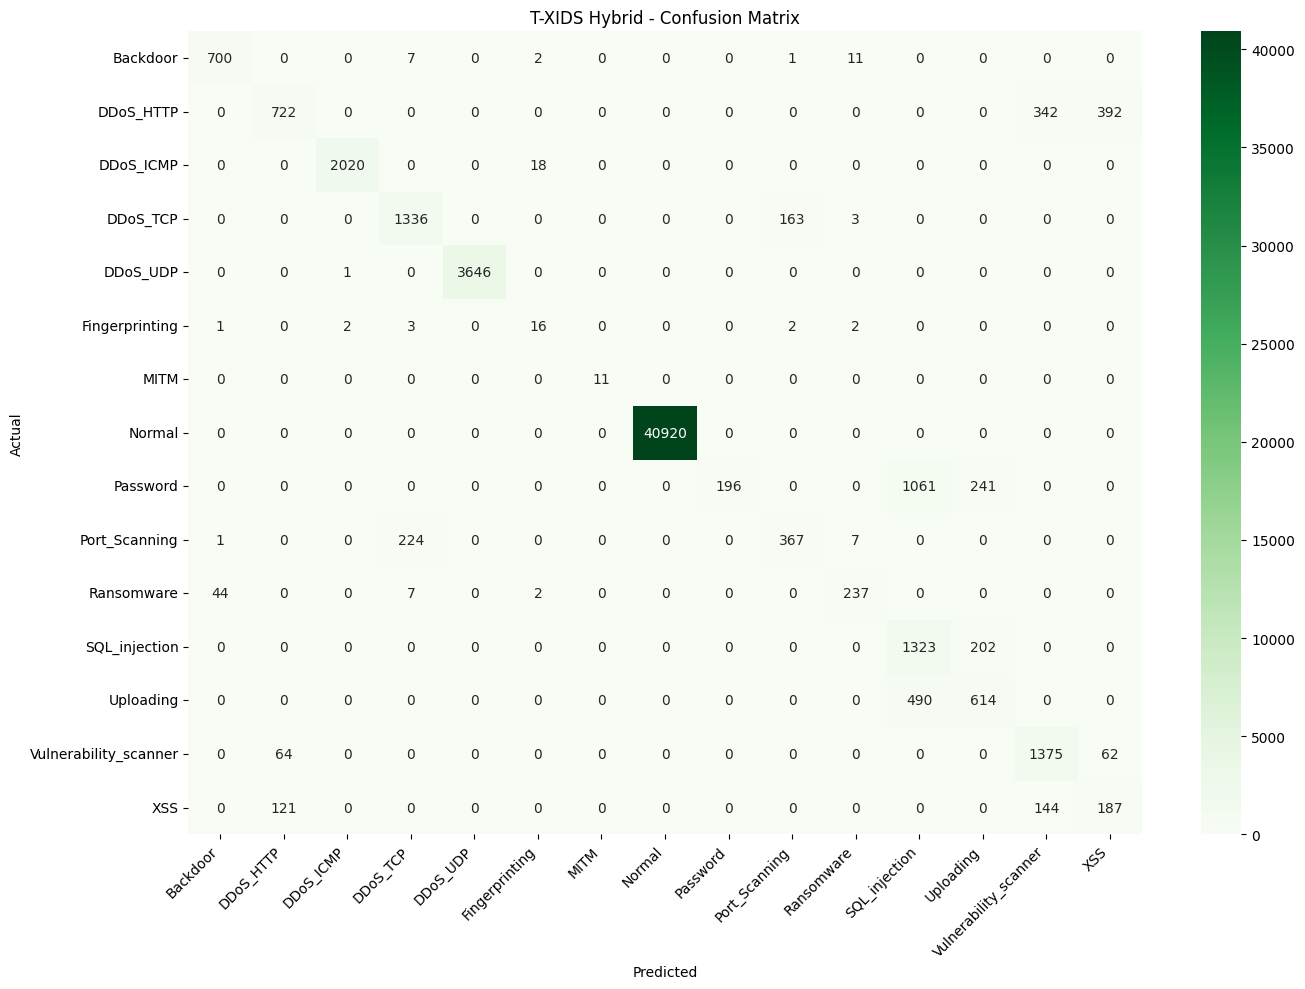

In [12]:
def build_txids(inp_shape, n_cls):
    inp = Input(shape=inp_shape)

    # CNN PATH
    c = Conv1D(64, 3, padding='same')(inp); c = BatchNormalization()(c); c = ReLU()(c)
    c = Conv1D(128, 5, padding='same')(c); c = BatchNormalization()(c); c = ReLU()(c)
    c = MaxPooling1D(2)(c)

    # BiLSTM PATH
    l = Bidirectional(LSTM(64, return_sequences=True))(inp); l = MaxPooling1D(2)(l)

    # MERGE + TRANSFORMER
    m = Concatenate(axis=-1)([c, l])
    a = MultiHeadAttention(num_heads=4, key_dim=32)(m, m); a = Dropout(0.1)(a)
    a = Add()([m, a]); a = LayerNormalization()(a)
    f = Dense(256, activation='relu')(a); f = Dropout(0.1)(f)
    f = Dense(a.shape[-1])(f); f = Add()([a, f]); f = LayerNormalization()(f)

    # CLASSIFICATION HEAD
    x = GlobalAveragePooling1D()(f)
    x = Dense(256, activation='relu')(x); x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x); x = Dropout(0.2)(x)
    out = Dense(n_cls, activation='softmax')(x)
    return Model(inp, out, name='T_XIDS')

txids = build_txids((num_features,1), num_classes)
txids.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
txids.summary()

h_txids = txids.fit(X_train_nn, y_train_oh, epochs=30, batch_size=256,
    validation_data=(X_val_nn, y_val_oh),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)], verbose=1)

y_p_tx = np.argmax(txids.predict(X_test_nn), axis=1)
tx_acc = accuracy_score(y_test, y_p_tx); tx_f1 = f1_score(y_test, y_p_tx, average='macro')
tx_fw = f1_score(y_test, y_p_tx, average='weighted'); tx_mcc = matthews_corrcoef(y_test, y_p_tx)

print(f'\n=== T-XIDS Hybrid Results ===')
print(f'Accuracy:     {tx_acc:.4f}')
print(f'F1 (macro):   {tx_f1:.4f}')
print(f'F1 (weighted):{tx_fw:.4f}')
print(f'MCC:          {tx_mcc:.4f}')
print(f'\n{classification_report(y_test, y_p_tx, target_names=class_names)}')

cm_tx = confusion_matrix(y_test, y_p_tx)
plt.figure(figsize=(14,10))
sns.heatmap(cm_tx, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('T-XIDS Hybrid - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('txids_cm.png', dpi=150, bbox_inches='tight'); plt.show()

# Model Comparison Table + Chart

MODEL COMPARISON - CLEAN DATA
          Model  Accuracy  F1 (macro)      MCC
  Random Forest  0.977850    0.897629 0.953958
            CNN  0.934194    0.740893 0.863354
         BiLSTM  0.934037    0.737605 0.863088
T-XIDS (Hybrid)  0.936813    0.733297 0.869571


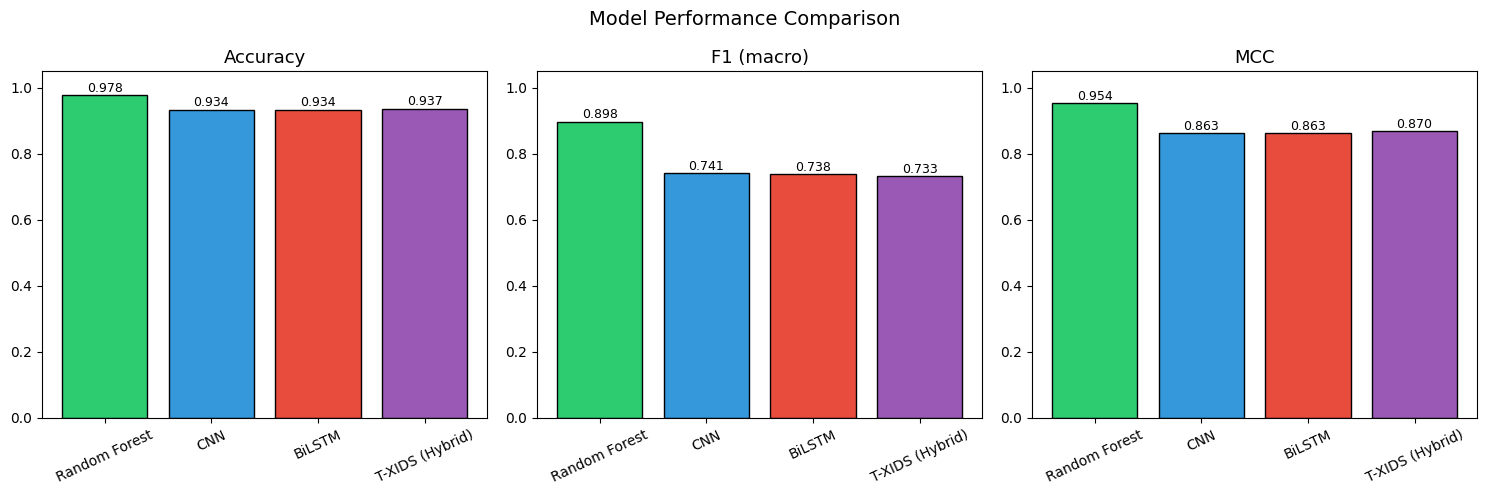

In [13]:
results = pd.DataFrame({'Model': ['Random Forest','CNN','BiLSTM','T-XIDS (Hybrid)'],
    'Accuracy': [rf_acc, cnn_acc, bl_acc, tx_acc],
    'F1 (macro)': [rf_f1, cnn_f1, bl_f1, tx_f1],
    'MCC': [rf_mcc, cnn_mcc, bl_mcc, tx_mcc]})

print('='*65); print('MODEL COMPARISON - CLEAN DATA'); print('='*65)
print(results.to_string(index=False)); print('='*65)

fig, axes = plt.subplots(1,3,figsize=(15,5))
colors = ['#2ecc71','#3498db','#e74c3c','#9b59b6']
for i, m in enumerate(['Accuracy','F1 (macro)','MCC']):
    axes[i].bar(results['Model'], results[m], color=colors, edgecolor='black')
    axes[i].set_title(m, fontsize=13); axes[i].set_ylim(0,1.05)
    axes[i].tick_params(axis='x', rotation=25)
    for j, v in enumerate(results[m]): axes[i].text(j, v+0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout(); plt.savefig('comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# Per-Class Performance Analysis

In [14]:
# PER-CLASS PERFORMANCE ANALYSIS
# Determines whic classes does each model handle best/worst?
from sklearn.metrics import classification_report

print('=== T-XIDS Per-Class Performance ===')
report_tx = classification_report(y_test, y_p_tx, target_names=class_names, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=class_names, output_dict=True)

print(f'\n{"Class":<25} {"RF F1":>8} {"T-XIDS F1":>10} {"Winner":>8} {"Support":>8}')
print('-'*62)
for cls in class_names:
    rf_f1_cls = report_rf[cls]['f1-score']
    tx_f1_cls = report_tx[cls]['f1-score']
    winner = 'RF' if rf_f1_cls > tx_f1_cls else 'T-XIDS' if tx_f1_cls > rf_f1_cls else 'Tie'
    support = report_rf[cls]['support']
    print(f'{cls:<25} {rf_f1_cls:>8.4f} {tx_f1_cls:>10.4f} {winner:>8} {support:>8.0f}')

=== T-XIDS Per-Class Performance ===

Class                        RF F1  T-XIDS F1   Winner  Support
--------------------------------------------------------------
Backdoor                    0.9736     0.9543       RF      721
DDoS_HTTP                   0.8277     0.6111       RF     1456
DDoS_ICMP                   0.9970     0.9948       RF     2038
DDoS_TCP                    1.0000     0.8678       RF     1502
DDoS_UDP                    1.0000     0.9999       RF     3647
Fingerprinting              0.6316     0.5000       RF       26
MITM                        1.0000     1.0000      Tie       11
Normal                      1.0000     1.0000      Tie    40920
Password                    0.8346     0.2314       RF     1498
Port_Scanning               0.9785     0.6484       RF      599
Ransomware                  0.9287     0.8618       RF      290
SQL_injection               0.8356     0.6015       RF     1525
Uploading                   0.8161     0.5683       RF     1104
Vul

# Training History Plots

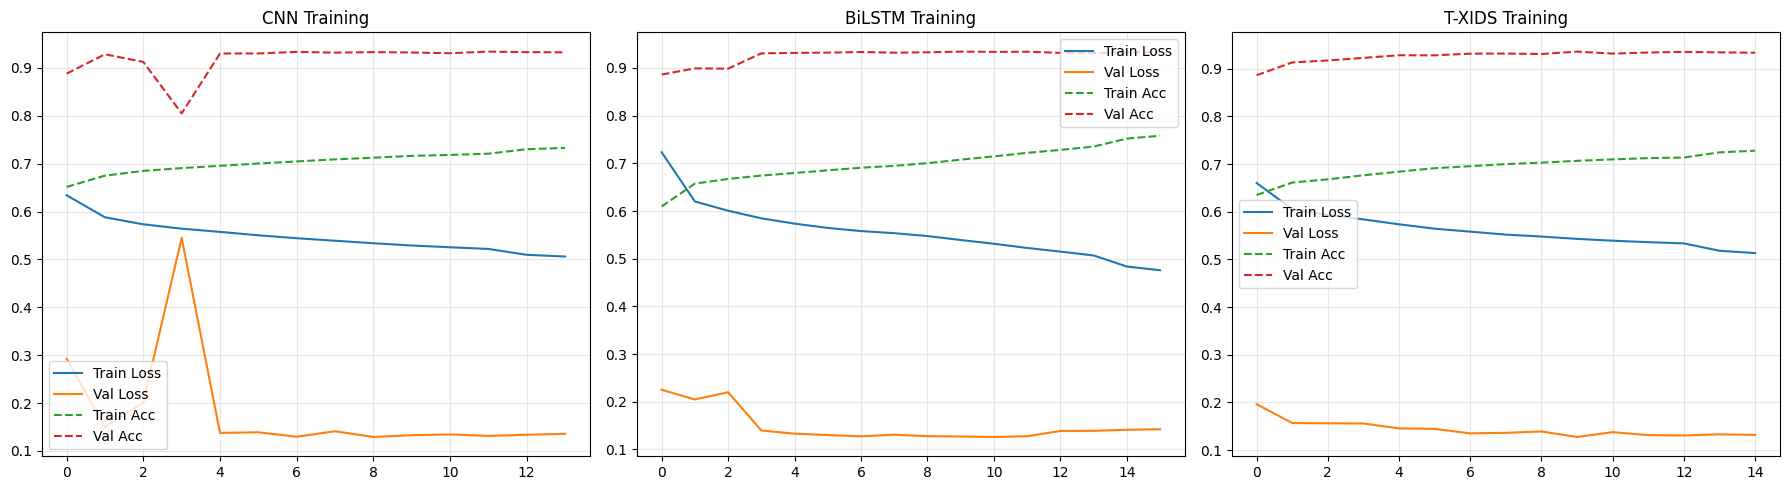

In [15]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
for i, (nm, h) in enumerate({'CNN':h_cnn,'BiLSTM':h_bilstm,'T-XIDS':h_txids}.items()):
    axes[i].plot(h.history['loss'], label='Train Loss')
    axes[i].plot(h.history['val_loss'], label='Val Loss')
    axes[i].plot(h.history['accuracy'], label='Train Acc', linestyle='--')
    axes[i].plot(h.history['val_accuracy'], label='Val Acc', linestyle='--')
    axes[i].set_title(f'{nm} Training'); axes[i].legend(); axes[i].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('histories.png', dpi=150, bbox_inches='tight'); plt.show()

# Save Model + ROC-AUC Curves

1791/1791 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


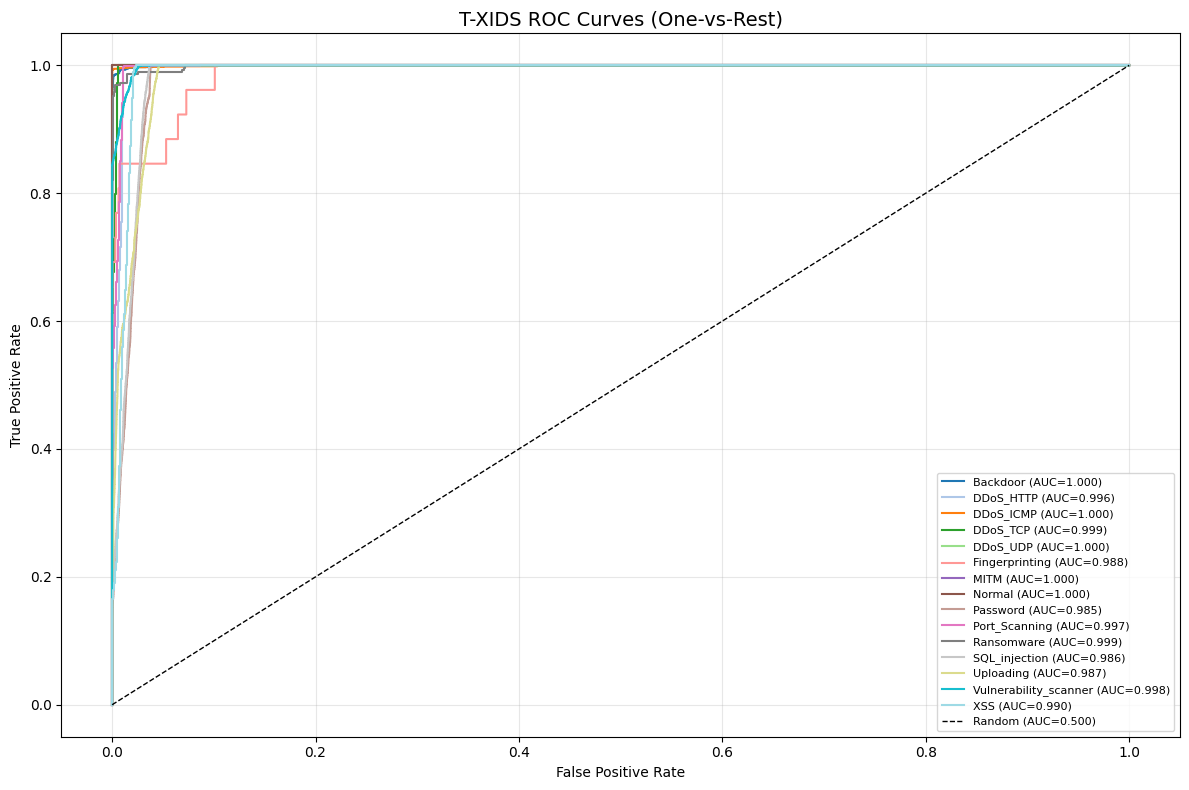

Macro-average AUC: 0.9949


In [16]:
txids.save('txids_model.keras')

# ROC-AUC for T-XIDS (multiclass one-vs-rest)
y_probs = txids.predict(X_test_nn)

plt.figure(figsize=(12, 8))
colors_roc = plt.cm.tab20(np.linspace(0, 1, num_classes))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_oh[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors_roc[i], lw=1.5,
        label=f'{class_names[i]} (AUC={roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('T-XIDS ROC Curves (One-vs-Rest)', fontsize=14)
plt.legend(fontsize=8, loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight'); plt.show()

macro_auc = roc_auc_score(y_test_oh, y_probs, multi_class='ovr', average='macro')
print(f'Macro-average AUC: {macro_auc:.4f}')

# FGSM Adversarial Attack

ADVERSARIAL ROBUSTNESS - FGSM
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
eps=0.01 | Acc:0.9310 | F1:0.7030 | dAcc:0.0058
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
eps=0.05 | Acc:0.9110 | F1:0.5782 | dAcc:0.0258
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
eps=0.10 | Acc:0.8850 | F1:0.4784 | dAcc:0.0518
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
eps=0.20 | Acc:0.8345 | F1:0.3552 | dAcc:0.1023


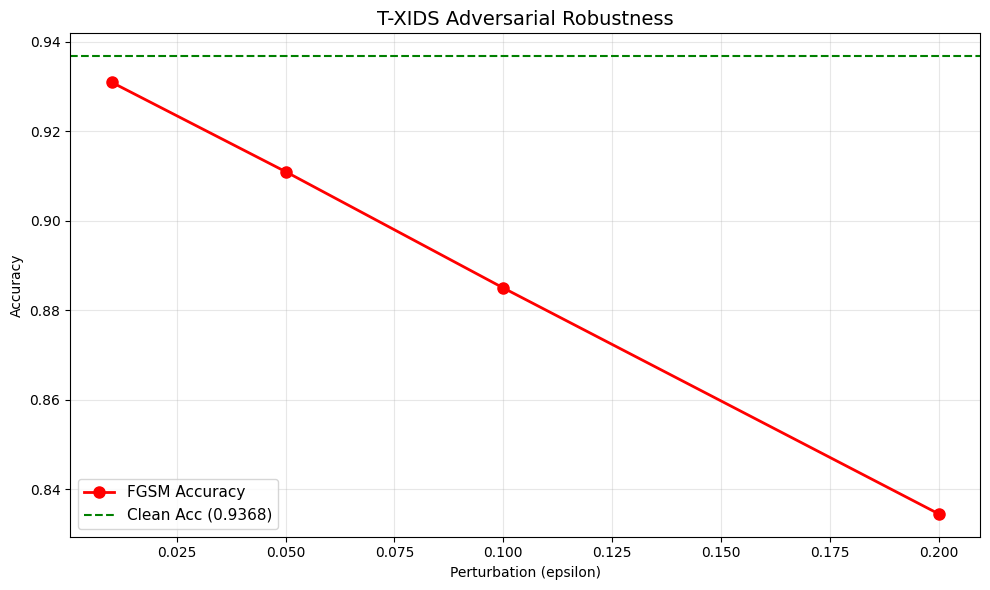

In [17]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod

art_cls = TensorFlowV2Classifier(model=txids, nb_classes=num_classes,
    input_shape=(num_features,1), loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(X_test_nn.min(), X_test_nn.max()))

epsilons = [0.01, 0.05, 0.1, 0.2]; adv_res = []
n_adv = 2000; X_adv_sub = X_test_nn[:n_adv]; y_adv_sub = y_test[:n_adv]

print('='*55); print('ADVERSARIAL ROBUSTNESS - FGSM'); print('='*55)
for eps in epsilons:
    fgsm = FastGradientMethod(estimator=art_cls, eps=eps)
    X_adv = fgsm.generate(x=X_adv_sub)
    y_p = np.argmax(txids.predict(X_adv), axis=1)
    a = accuracy_score(y_adv_sub, y_p); f = f1_score(y_adv_sub, y_p, average='macro')
    d = tx_acc - a
    adv_res.append({'eps':eps,'Acc':a,'F1':f,'dAcc':d})
    print(f'eps={eps:.2f} | Acc:{a:.4f} | F1:{f:.4f} | dAcc:{d:.4f}')

adv_df = pd.DataFrame(adv_res)

plt.figure(figsize=(10,6))
plt.plot(epsilons, [r['Acc'] for r in adv_res], 'o-', color='red', lw=2, ms=8, label='FGSM Accuracy')
plt.axhline(y=tx_acc, color='green', ls='--', label=f'Clean Acc ({tx_acc:.4f})')
plt.xlabel('Perturbation (epsilon)'); plt.ylabel('Accuracy')
plt.title('T-XIDS Adversarial Robustness', fontsize=14)
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('adv_robustness.png', dpi=150, bbox_inches='tight'); plt.show()

# Adversarial Robustness Comparison — All Models

ADVERSARIAL ROBUSTNESS COMPARISON ACROSS MODELS
eps=0.01 | RF:0.9070 | CNN:0.9295 | BiLSTM:0.9230 | T-XIDS:0.9310
eps=0.05 | RF:0.8975 | CNN:0.9140 | BiLSTM:0.9065 | T-XIDS:0.9110
eps=0.10 | RF:0.8855 | CNN:0.8865 | BiLSTM:0.8750 | T-XIDS:0.8850
eps=0.20 | RF:0.8635 | CNN:0.8130 | BiLSTM:0.8370 | T-XIDS:0.8345


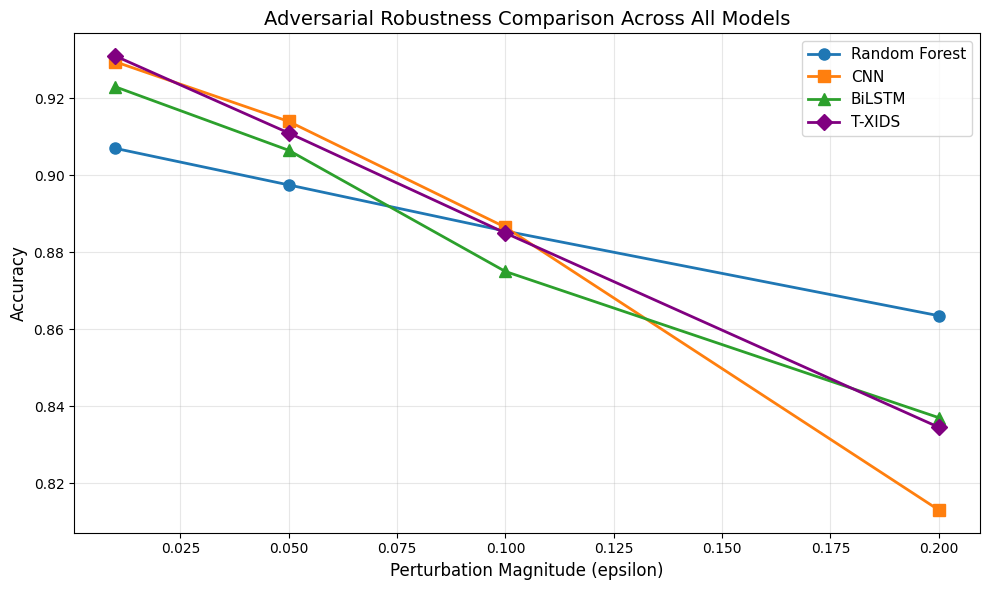

In [18]:
# ADVERSARIAL COMPARISON: ALL MODELS
print('='*65)
print('ADVERSARIAL ROBUSTNESS COMPARISON ACROSS MODELS')
print('='*65)

adv_comparison = []

for eps in [0.01, 0.05, 0.1, 0.2]:
    fgsm = FastGradientMethod(estimator=art_cls, eps=eps)
    X_adv = fgsm.generate(x=X_test_nn[:2000])
    X_adv_flat = X_adv.reshape(2000, -1)
    y_sub = y_test[:2000]
    
    # RF
    rf_a = accuracy_score(y_sub, rf.predict(X_adv_flat))
    # CNN
    cnn_a = accuracy_score(y_sub, np.argmax(cnn.predict(X_adv, verbose=0), axis=1))
    # BiLSTM
    bl_a = accuracy_score(y_sub, np.argmax(bilstm.predict(X_adv, verbose=0), axis=1))
    # T-XIDS
    tx_a = accuracy_score(y_sub, np.argmax(txids.predict(X_adv, verbose=0), axis=1))
    
    adv_comparison.append({'eps': eps, 'RF': rf_a, 'CNN': cnn_a, 'BiLSTM': bl_a, 'T-XIDS': tx_a})
    print(f'eps={eps:.2f} | RF:{rf_a:.4f} | CNN:{cnn_a:.4f} | BiLSTM:{bl_a:.4f} | T-XIDS:{tx_a:.4f}')

# Plot
adv_comp_df = pd.DataFrame(adv_comparison)
plt.figure(figsize=(10, 6))
plt.plot(adv_comp_df['eps'], adv_comp_df['RF'], 'o-', label='Random Forest', lw=2, ms=8)
plt.plot(adv_comp_df['eps'], adv_comp_df['CNN'], 's-', label='CNN', lw=2, ms=8)
plt.plot(adv_comp_df['eps'], adv_comp_df['BiLSTM'], '^-', label='BiLSTM', lw=2, ms=8)
plt.plot(adv_comp_df['eps'], adv_comp_df['T-XIDS'], 'D-', label='T-XIDS', lw=2, ms=8, color='purple')
plt.xlabel('Perturbation Magnitude (epsilon)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Adversarial Robustness Comparison Across All Models', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('adv_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP Explainability

Computing SHAP values...


  0%|          | 0/200 [00:00<?, ?it/s]

Done!


<Figure size 1200x800 with 0 Axes>

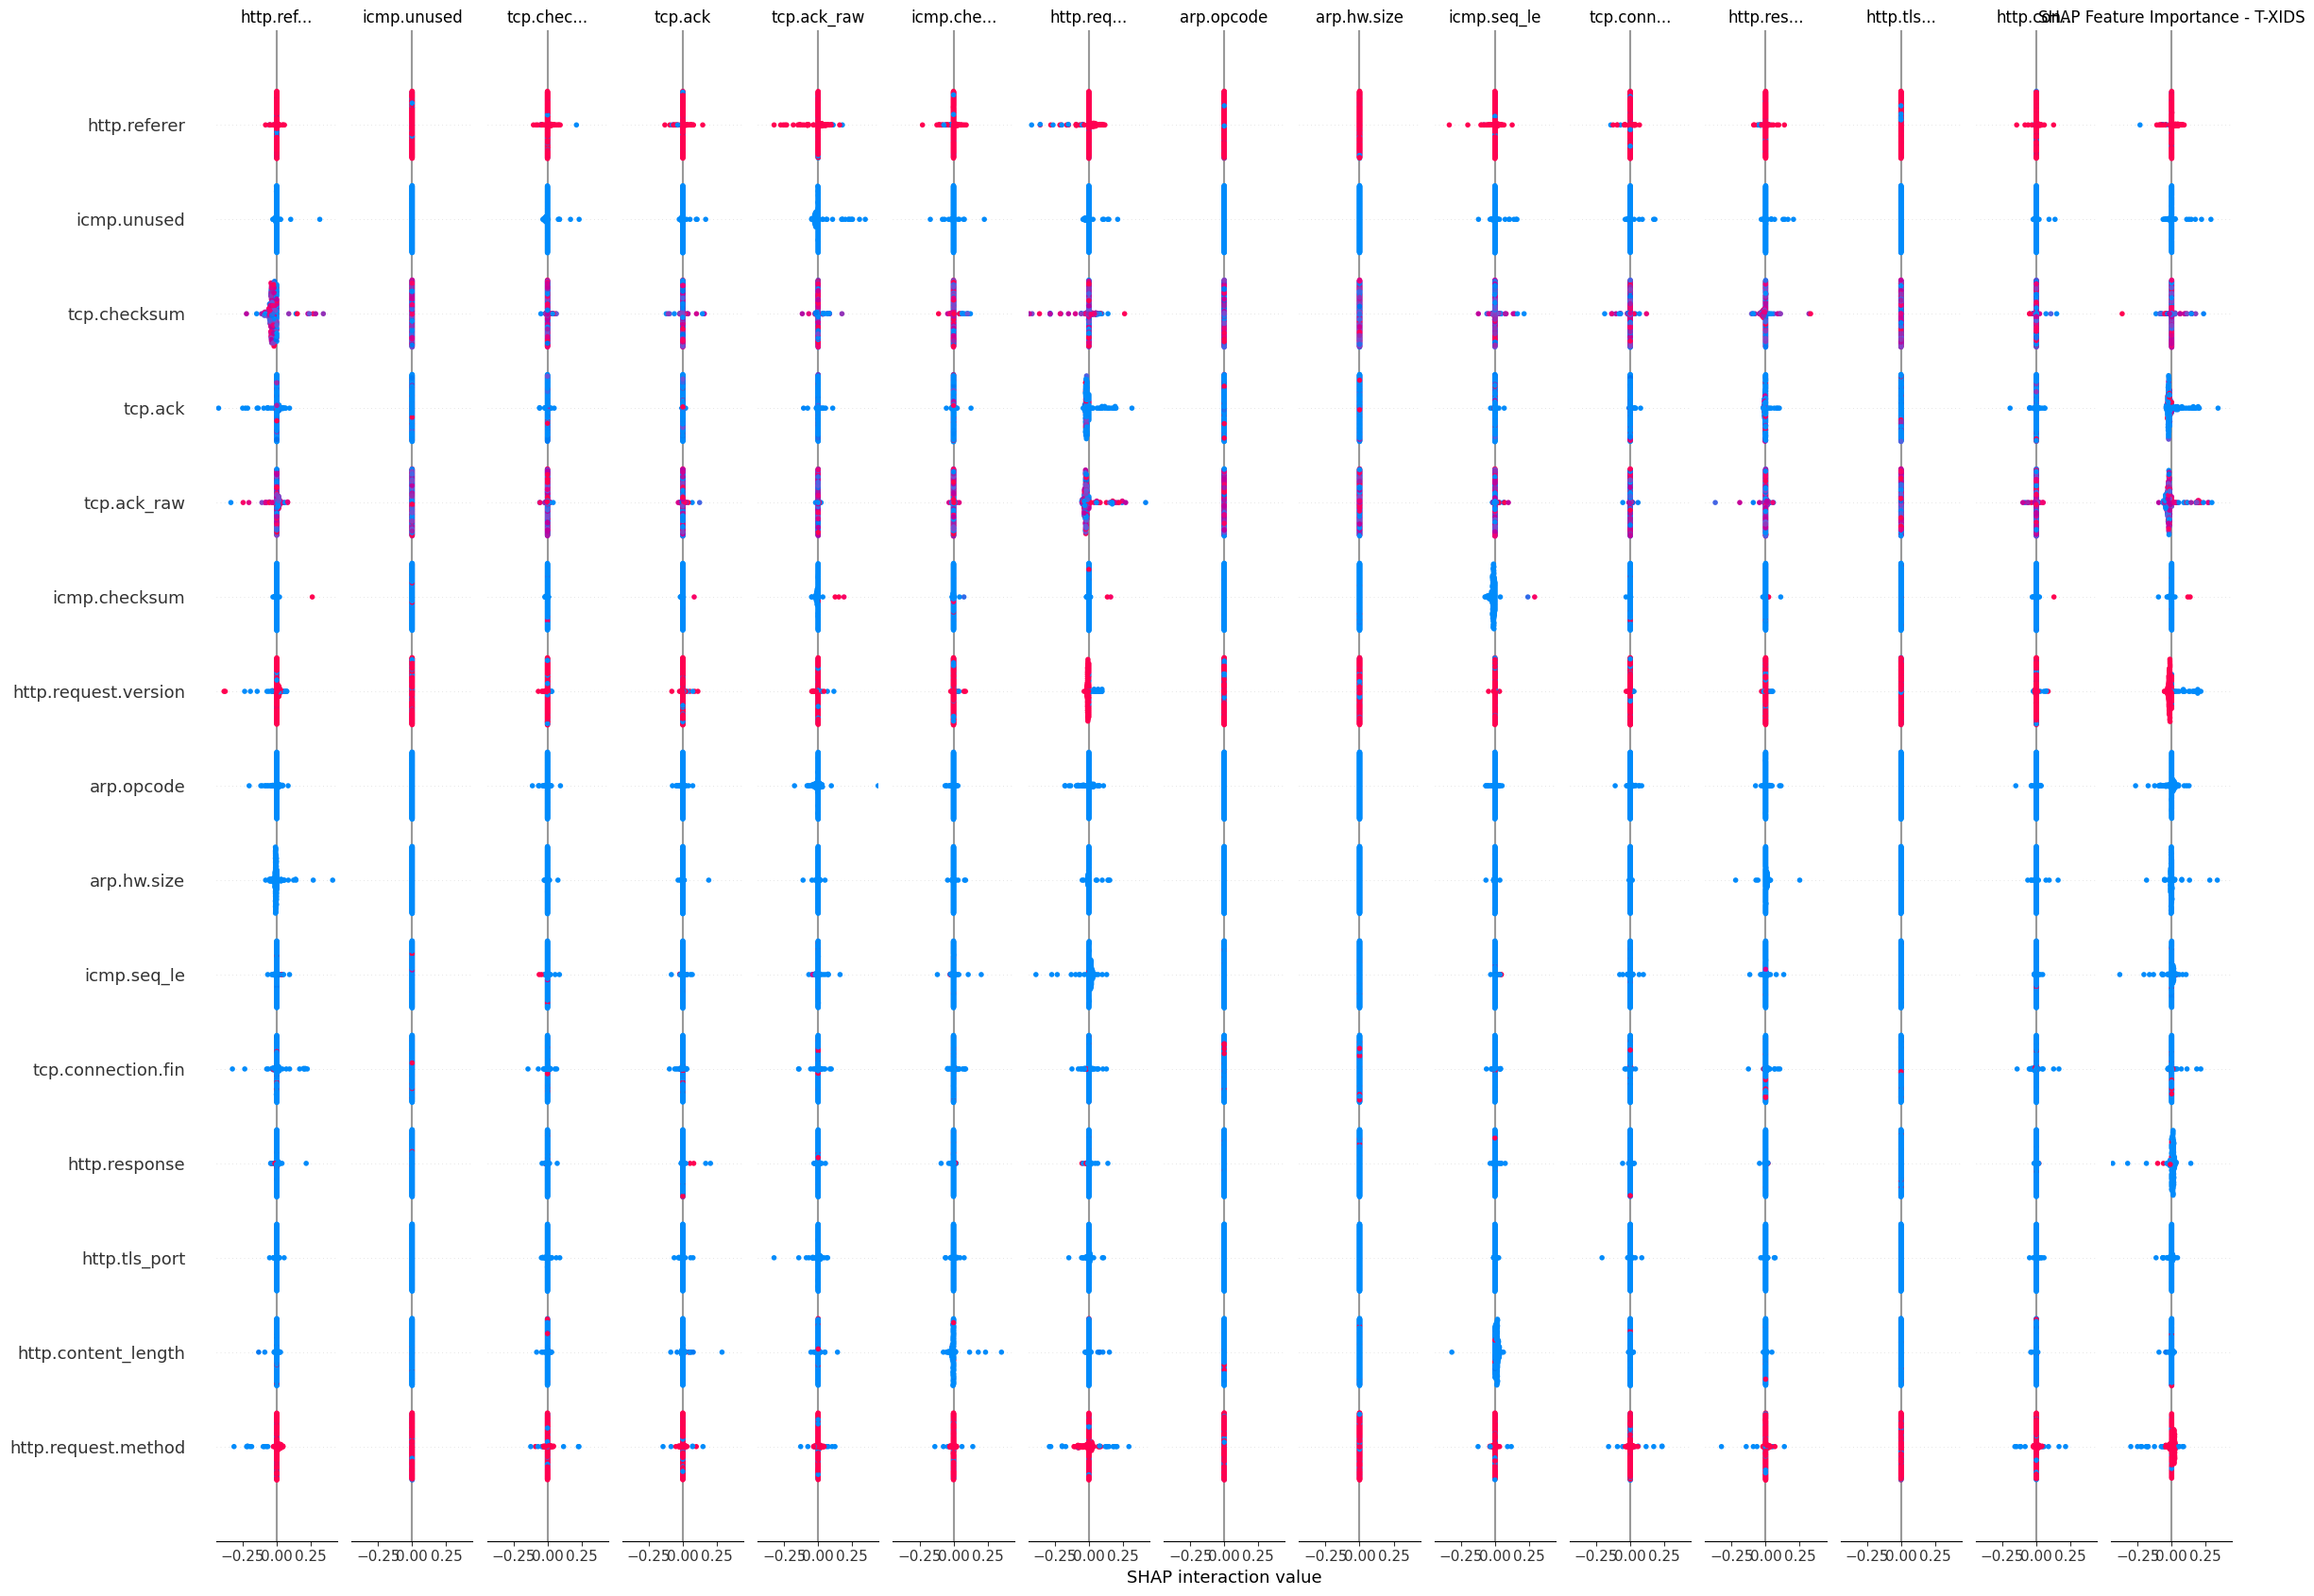

In [19]:
import shap

background = X_test_nn[:100]

def predict_shap(x): return txids.predict(x.reshape(-1, num_features, 1), verbose=0)

print('Computing SHAP values...')
explainer = shap.KernelExplainer(predict_shap, background.reshape(100, num_features))
shap_sample = X_test_nn[:200].reshape(200, num_features)
shap_values = explainer.shap_values(shap_sample, nsamples=100)
print('Done!')

feature_names = list(X.columns)
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, max_display=20, show=False)
plt.title('SHAP Feature Importance - T-XIDS'); plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight'); plt.show()

# SHAP Attribution Fingerprinting — NOVEL CONTRIBUTION

  0%|          | 0/300 [00:00<?, ?it/s]

Clean SHAP shape: (300, 47)
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


  0%|          | 0/300 [00:00<?, ?it/s]

Adversarial SHAP shape: (300, 47)
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
SHAP FINGERPRINTING RESULTS (eps=0.1)
False Positive Rate: 15/300 (5.0%)
Detection Rate:      35/300 (11.7%)


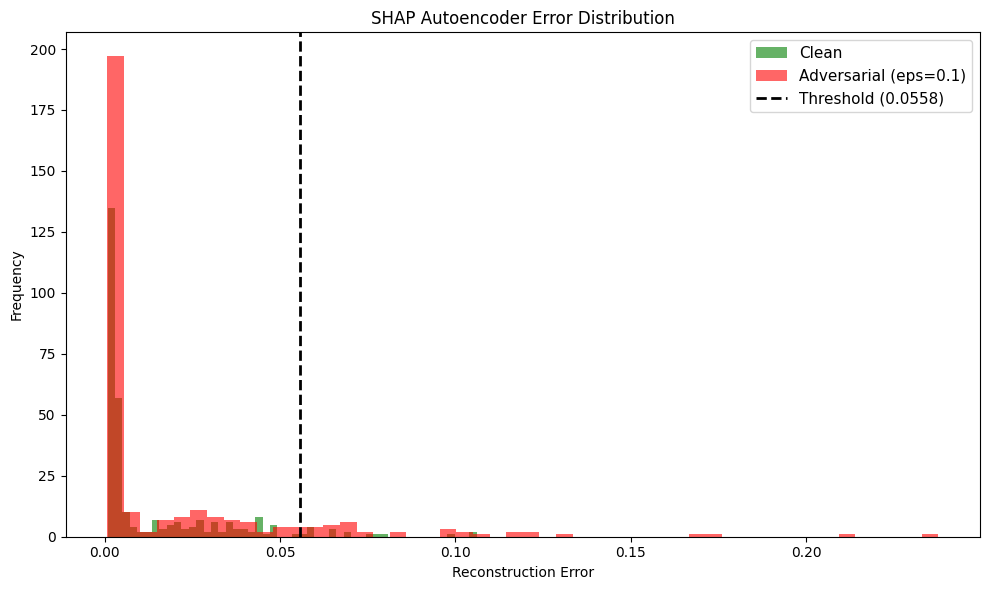

In [20]:
from sklearn.preprocessing import MinMaxScaler

# SHAP for clean samples
n_fp = 300
clean_sv = explainer.shap_values(X_test_nn[:n_fp].reshape(n_fp, num_features), nsamples=50)
if isinstance(clean_sv, list):
    clean_agg = np.mean([np.abs(sv) for sv in clean_sv], axis=0)
else:
    clean_agg = np.abs(clean_sv)

# Fix: ensure 2D shape (samples, features)
if clean_agg.ndim == 3:
    clean_agg = np.mean(clean_agg, axis=-1)
print(f'Clean SHAP shape: {clean_agg.shape}')

# Train autoencoder on clean SHAP values
shap_scaler = MinMaxScaler()
clean_norm = shap_scaler.fit_transform(clean_agg)

ae_inp = Input(shape=(num_features,))
enc = Dense(64, activation='relu')(ae_inp); enc = Dense(16, activation='relu')(enc)
dec = Dense(64, activation='relu')(enc); dec = Dense(num_features, activation='sigmoid')(dec)
ae = Model(ae_inp, dec, name='SHAP_AE')
ae.compile(optimizer='adam', loss='mse')
ae.fit(clean_norm, clean_norm, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Threshold from clean errors
clean_recon = ae.predict(clean_norm)
clean_err = np.mean((clean_norm - clean_recon)**2, axis=1)
threshold = np.percentile(clean_err, 95)

# Test on adversarial samples
fgsm_fp = FastGradientMethod(estimator=art_cls, eps=0.1)
X_adv_fp = fgsm_fp.generate(x=X_test_nn[:n_fp])
adv_sv = explainer.shap_values(X_adv_fp.reshape(n_fp, num_features), nsamples=50)
if isinstance(adv_sv, list):
    adv_agg = np.mean([np.abs(sv) for sv in adv_sv], axis=0)
else:
    adv_agg = np.abs(adv_sv)

if adv_agg.ndim == 3:
    adv_agg = np.mean(adv_agg, axis=-1)
print(f'Adversarial SHAP shape: {adv_agg.shape}')
adv_norm = shap_scaler.transform(adv_agg)

adv_recon = ae.predict(adv_norm)
adv_err = np.mean((adv_norm - adv_recon)**2, axis=1)

c_det = np.sum(clean_err > threshold); a_det = np.sum(adv_err > threshold)

print('='*55)
print('SHAP FINGERPRINTING RESULTS (eps=0.1)')
print('='*55)
print(f'False Positive Rate: {c_det}/{n_fp} ({c_det/n_fp*100:.1f}%)')
print(f'Detection Rate:      {a_det}/{n_fp} ({a_det/n_fp*100:.1f}%)')
print('='*55)

plt.figure(figsize=(10,6))
plt.hist(clean_err, bins=50, alpha=0.6, color='green', label='Clean')
plt.hist(adv_err, bins=50, alpha=0.6, color='red', label='Adversarial (eps=0.1)')
plt.axvline(x=threshold, color='black', ls='--', lw=2, label=f'Threshold ({threshold:.4f})')
plt.xlabel('Reconstruction Error'); plt.ylabel('Frequency')
plt.title('SHAP Autoencoder Error Distribution'); plt.legend(fontsize=11); plt.tight_layout()
plt.savefig('shap_fingerprint.png', dpi=150, bbox_inches='tight'); plt.show()

# Multi-epsilon Fingerprinting 

In [24]:
# Test fingerprinting at higher perturbation levels
multi_eps_results = [{'eps': 0.1, 'det': a_det, 'rate': a_det/n_fp*100}]

for test_eps in [0.2, 0.3, 0.5]:
    fgsm_t = FastGradientMethod(estimator=art_cls, eps=test_eps)
    X_adv_t = fgsm_t.generate(x=X_test_nn[:n_fp])
    adv_sv_t = explainer.shap_values(X_adv_t.reshape(n_fp, num_features), nsamples=50)
    
    if isinstance(adv_sv_t, list):
        adv_agg_t = np.mean([np.abs(sv) for sv in adv_sv_t], axis=0)
    else:
        adv_agg_t = np.abs(adv_sv_t)
    if adv_agg_t.ndim == 3:
        adv_agg_t = np.mean(adv_agg_t, axis=-1)
    
    adv_norm_t = shap_scaler.transform(adv_agg_t)
    adv_recon_t = ae.predict(adv_norm_t, verbose=0)
    adv_err_t = np.mean((adv_norm_t - adv_recon_t)**2, axis=1)
    det = np.sum(adv_err_t > threshold)
    multi_eps_results.append({'eps': test_eps, 'det': det, 'rate': det/n_fp*100})
    print(f'eps={test_eps:.1f} | Detected: {det}/{n_fp} ({det/n_fp*100:.1f}%)')

  0%|          | 0/300 [00:00<?, ?it/s]

eps=0.2 | Detected: 18/300 (6.0%)


  0%|          | 0/300 [00:00<?, ?it/s]

eps=0.3 | Detected: 41/300 (13.7%)


  0%|          | 0/300 [00:00<?, ?it/s]

eps=0.5 | Detected: 54/300 (18.0%)


# SHAP Fingerprinting Across Epsilon Levels

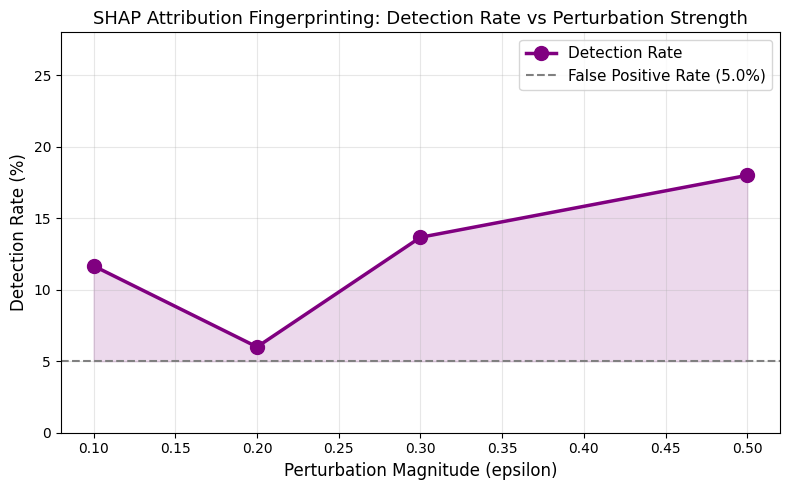

SHAP Fingerprinting Summary:
  eps=0.1 | Detection: 11.7% | FPR: 5.0% | Net Gain: 6.7%
  eps=0.2 | Detection: 6.0% | FPR: 5.0% | Net Gain: 1.0%
  eps=0.3 | Detection: 13.7% | FPR: 5.0% | Net Gain: 8.7%
  eps=0.5 | Detection: 18.0% | FPR: 5.0% | Net Gain: 13.0%


In [25]:
all_eps = [r['eps'] for r in multi_eps_results]
all_det = [r['rate'] for r in multi_eps_results]

plt.figure(figsize=(8, 5))
plt.plot(all_eps, all_det, 'o-', color='purple', lw=2.5, ms=10, label='Detection Rate')
plt.axhline(y=5.0, color='gray', ls='--', lw=1.5, label='False Positive Rate (5.0%)')
plt.fill_between(all_eps, 5.0, all_det, alpha=0.15, color='purple')
plt.xlabel('Perturbation Magnitude (epsilon)', fontsize=12)
plt.ylabel('Detection Rate (%)', fontsize=12)
plt.title('SHAP Attribution Fingerprinting: Detection Rate vs Perturbation Strength', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim(0, max(all_det)+10)
plt.tight_layout()
plt.savefig('fingerprint_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()

print('SHAP Fingerprinting Summary:')
for r in multi_eps_results:
    print(f'  eps={r["eps"]:.1f} | Detection: {r["rate"]:.1f}% | FPR: 5.0% | Net Gain: {r["rate"]-5.0:.1f}%')

# Final Summary

In [26]:
print('='*65)
print('COMPLETE EXPERIMENTAL RESULTS SUMMARY')
print('='*65)

print('\n--- Table 1: Model Comparison on Clean Data ---')
print(results.to_string(index=False))

print('\n--- Table 2: T-XIDS Adversarial Robustness (FGSM) ---')
print(adv_df.to_string(index=False))

print('\n--- Table 3: Adversarial Robustness Comparison (All Models) ---')
print(adv_comp_df.to_string(index=False))

print('\n--- Table 4: SHAP Attribution Fingerprinting ---')
for r in multi_eps_results:
    print(f'  eps={r["eps"]:.1f} | Detection: {r["rate"]:.1f}% | FPR: 5.0%')

print(f'\n--- Table 5: Key Metrics ---')
print(f'  T-XIDS Macro-Average AUC: {macro_auc:.4f}')
print(f'  T-XIDS Clean Accuracy:    {tx_acc:.4f}')
print(f'  RF Clean Accuracy:        {rf_acc:.4f}')
print(f'  Accuracy Drop at eps=0.2: {adv_res[3]["dAcc"]:.4f}')
print('='*65)

COMPLETE EXPERIMENTAL RESULTS SUMMARY

--- Table 1: Model Comparison on Clean Data ---
          Model  Accuracy  F1 (macro)      MCC
  Random Forest  0.977850    0.897629 0.953958
            CNN  0.934194    0.740893 0.863354
         BiLSTM  0.934037    0.737605 0.863088
T-XIDS (Hybrid)  0.936813    0.733297 0.869571

--- Table 2: T-XIDS Adversarial Robustness (FGSM) ---
 eps    Acc       F1     dAcc
0.01 0.9310 0.703019 0.005813
0.05 0.9110 0.578179 0.025813
0.10 0.8850 0.478422 0.051813
0.20 0.8345 0.355187 0.102313

--- Table 3: Adversarial Robustness Comparison (All Models) ---
 eps     RF    CNN  BiLSTM  T-XIDS
0.01 0.9070 0.9295  0.9230  0.9310
0.05 0.8975 0.9140  0.9065  0.9110
0.10 0.8855 0.8865  0.8750  0.8850
0.20 0.8635 0.8130  0.8370  0.8345

--- Table 4: SHAP Attribution Fingerprinting ---
  eps=0.1 | Detection: 11.7% | FPR: 5.0%
  eps=0.2 | Detection: 6.0% | FPR: 5.0%
  eps=0.3 | Detection: 13.7% | FPR: 5.0%
  eps=0.5 | Detection: 18.0% | FPR: 5.0%

--- Table 5: Key Me